## Selección del Mejor Modelo - Dataset Boston Housing

### By:
Rafael Garcia

### Date:
2026-08-20

### Description:

Este notebook corresponde a la **Tarea 6: Selección del mejor modelo** del Proyecto 1 (Dataset Estático) del curso de MLOps.

El objetivo es seleccionar el mejor modelo de machine learning para predecir el precio de viviendas en Boston, superando el modelo baseline (RMSE ~9.22, R² ~0.0) establecido en la Tarea 5. Se incluye:

- Evaluación de múltiples modelos (mínimo 4 tipos diferentes)
- Eliminación de modelos por debajo del promedio
- Validación cruzada de los mejores modelos
- Optimización de hiperparámetros
- Comparación estadística para seleccionar el mejor modelo
- Evaluación final en test
- Análisis de Learning Curve y escalabilidad
- Almacenamiento del pipeline final

## 📚 Import libraries

In [1]:
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 5)

## 💾 Load data

In [2]:
df = pd.read_parquet("../../data/02_intermediate/boston_housing_clean.parquet")

TARGET = "medv"
ID_COL = "ID"

df = df.drop(columns=[ID_COL])
df = df.dropna(subset=[TARGET])

X = df.drop(columns=[TARGET])
y = df[TARGET]

TEST_SIZE = 0.2
RANDOM_STATE = 42
N_FOLDS = 10

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Convertir tipos para compatibilidad con el pipeline
for dataset in [X_train, X_test, X]:
    dataset["chas"] = dataset["chas"].astype(str)
    dataset["rad"] = dataset["rad"].astype(float)

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")

Train: 345 filas | Test: 87 filas


In [3]:
# Cargar preprocessor de la Tarea 4
preprocessor = joblib.load("../../models/preprocessor.joblib")
print("Preprocessor cargado correctamente")

Preprocessor cargado correctamente


## 🏗️ Paso 1: Definición de modelos candidatos

Se evalúan 6 tipos de modelos diferentes:

| # | Modelo | Tipo | Justificación |
|---|--------|------|---------------|
| 1 | Ridge | Lineal regularizado (L2) | Maneja multicolinealidad detectada en EDA |
| 2 | Lasso | Lineal regularizado (L1) | Selección automática de features |
| 3 | ElasticNet | Lineal regularizado (L1+L2) | Combina ventajas de Ridge y Lasso |
| 4 | Random Forest | Ensemble (bagging) | Captura relaciones no lineales |
| 5 | Gradient Boosting | Ensemble (boosting) | Alto rendimiento en datos tabulares |
| 6 | SVR | Kernel | Enfoque diferente, kernel RBF |

In [4]:
# Crear pipelines completos (preprocessor + modelo)
MODELS = {
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE),
    "ElasticNet": ElasticNet(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "SVR": SVR(),
}


def create_pipeline(model):
    """Crea un pipeline con preprocessor + modelo."""
    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


pipelines = {name: create_pipeline(model) for name, model in MODELS.items()}
print(f"Modelos candidatos: {len(pipelines)}")
for name in pipelines:
    print(f"  - {name}")

Modelos candidatos: 6
  - Ridge
  - Lasso
  - ElasticNet
  - Random Forest
  - Gradient Boosting
  - SVR


## 📏 Paso 2: Evaluación inicial con validación cruzada

In [5]:
SCORING = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

# Evaluar todos los modelos con cross validation
cv_results = {}
print("=== Evaluación inicial con Cross Validation ===")
print(f"{'Modelo':<20} {'RMSE':>10} {'±':>3} {'Std':>8} {'R²':>10} {'±':>3} {'Std':>8}")
print("-" * 65)

for name, pipeline in pipelines.items():
    cv = cross_validate(
        pipeline, X_train, y_train, cv=N_FOLDS, scoring=SCORING, return_train_score=True
    )
    cv_results[name] = cv

    rmse_scores = -cv["test_RMSE"]
    r2_scores = cv["test_R2"]
    print(
        f"{name:<20} {rmse_scores.mean():>10.4f} {'±':>3} {rmse_scores.std():>8.4f}"
        f" {r2_scores.mean():>10.4f} {'±':>3} {r2_scores.std():>8.4f}"
    )

=== Evaluación inicial con Cross Validation ===
Modelo                     RMSE   ±      Std         R²   ±      Std
-----------------------------------------------------------------
Ridge                    4.1344   ±   0.8605     0.7641   ±   0.0786
Lasso                    4.8363   ±   1.0637     0.6851   ±   0.0802
ElasticNet               5.1476   ±   1.1762     0.6475   ±   0.0767
Random Forest            2.7098   ±   0.7636     0.8991   ±   0.0434
Gradient Boosting        2.4841   ±   0.6334     0.9118   ±   0.0506
SVR                      5.0922   ±   1.6737     0.6709   ±   0.0952


In [6]:
# Crear DataFrame resumen
summary_rows = []
for name, cv in cv_results.items():
    rmse_scores = -cv["test_RMSE"]
    r2_scores = cv["test_R2"]
    mae_scores = -cv["test_MAE"]
    summary_rows.append(
        {
            "Modelo": name,
            "RMSE_mean": rmse_scores.mean(),
            "RMSE_std": rmse_scores.std(),
            "MAE_mean": mae_scores.mean(),
            "R2_mean": r2_scores.mean(),
            "R2_std": r2_scores.std(),
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("Modelo").sort_values("RMSE_mean")
summary_df.round(4)

,RMSE_mean,RMSE_std,MAE_mean,R2_mean,R2_std
Modelo,,,,,
Gradient Boosting,2.4841,0.6334,1.7815,0.9118,0.0506
Random Forest,2.7098,0.7636,1.8715,0.8991,0.0434
Ridge,4.1344,0.8605,3.0038,0.7641,0.0786
Lasso,4.8363,1.0637,3.4095,0.6851,0.0802
SVR,5.0922,1.6737,3.1161,0.6709,0.0952
ElasticNet,5.1476,1.1762,3.5145,0.6475,0.0767


## 🗑️ Paso 3: Eliminar modelos por debajo del promedio

In [7]:
# Calcular el RMSE promedio de todos los modelos
avg_rmse = summary_df["RMSE_mean"].mean()
print(f"RMSE promedio de todos los modelos: {avg_rmse:.4f}")
print()

# Separar modelos que superan y no superan el promedio
good_models = summary_df[summary_df["RMSE_mean"] <= avg_rmse].index.tolist()
bad_models = summary_df[summary_df["RMSE_mean"] > avg_rmse].index.tolist()

print(f"Modelos que pasan el filtro ({len(good_models)}):")
for name in good_models:
    rmse = summary_df.loc[name, "RMSE_mean"]
    print(f"  ✅ {name}: RMSE = {rmse:.4f}")

print(f"\nModelos eliminados ({len(bad_models)}):")
for name in bad_models:
    rmse = summary_df.loc[name, "RMSE_mean"]
    print(f"  ❌ {name}: RMSE = {rmse:.4f}")

RMSE promedio de todos los modelos: 4.0674

Modelos que pasan el filtro (2):
  ✅ Gradient Boosting: RMSE = 2.4841
  ✅ Random Forest: RMSE = 2.7098

Modelos eliminados (4):
  ❌ Ridge: RMSE = 4.1344
  ❌ Lasso: RMSE = 4.8363
  ❌ SVR: RMSE = 5.0922
  ❌ ElasticNet: RMSE = 5.1476


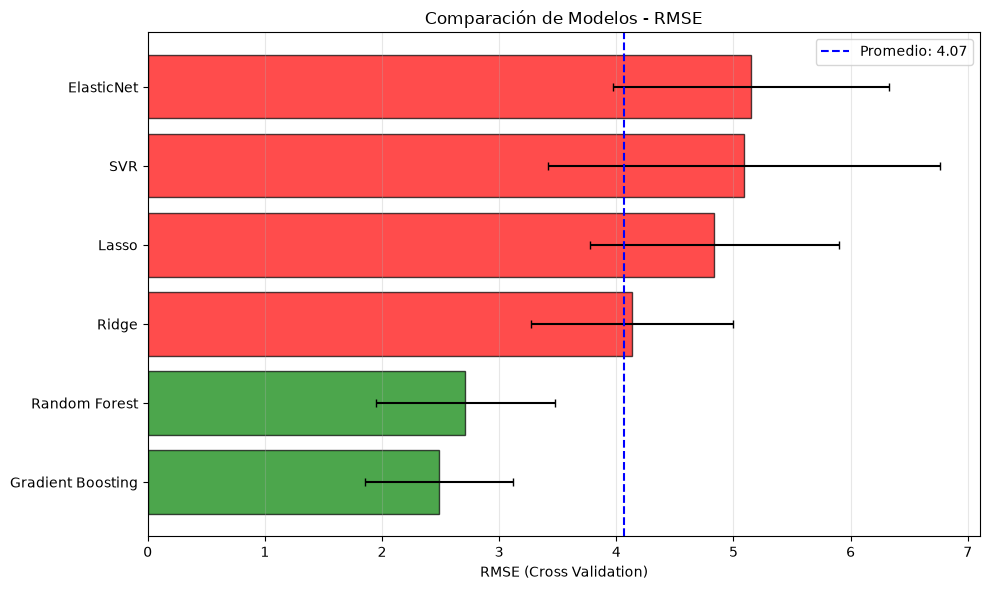

In [8]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 6))

models_sorted = summary_df.sort_values("RMSE_mean")
colors = ["green" if name in good_models else "red" for name in models_sorted.index]

bars = ax.barh(
    models_sorted.index, models_sorted["RMSE_mean"], color=colors, edgecolor="black", alpha=0.7
)
ax.errorbar(
    models_sorted["RMSE_mean"],
    models_sorted.index,
    xerr=models_sorted["RMSE_std"],
    fmt="none",
    color="black",
    capsize=3,
)
ax.axvline(avg_rmse, color="blue", linestyle="--", label=f"Promedio: {avg_rmse:.2f}")
ax.set_xlabel("RMSE (Cross Validation)")
ax.set_title("Comparación de Modelos - RMSE")
ax.legend()
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## 🔧 Paso 4: Optimización de hiperparámetros

Se realiza optimización de hiperparámetros para los 3 mejores modelos usando GridSearchCV con cross validation.

In [9]:
# Seleccionar los 3 mejores modelos
TOP_N = 3
top_models = summary_df.head(TOP_N).index.tolist()
print(f"Top {TOP_N} modelos para optimización de hiperparámetros:")
for name in top_models:
    print(f"  - {name} (RMSE: {summary_df.loc[name, 'RMSE_mean']:.4f})")

Top 3 modelos para optimización de hiperparámetros:
  - Gradient Boosting (RMSE: 2.4841)
  - Random Forest (RMSE: 2.7098)
  - Ridge (RMSE: 4.1344)


In [10]:
# Definir grids de hiperparámetros para cada modelo
PARAM_GRIDS = {
    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    },
    "Lasso": {
        "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    },
    "ElasticNet": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [5, 10, 20, None],
        "model__min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.1, 0.2],
    },
    "SVR": {
        "model__C": [0.1, 1.0, 10.0, 100.0],
        "model__epsilon": [0.01, 0.1, 0.5],
        "model__kernel": ["rbf", "linear"],
    },
}

In [11]:
# Optimización de hiperparámetros
best_estimators = {}
grid_results = {}

print("=== Optimización de Hiperparámetros ===")
for name in top_models:
    print(f"\nOptimizando {name}...")
    pipeline = pipelines[name]
    param_grid = PARAM_GRIDS[name]

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=N_FOLDS,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        return_train_score=True,
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = time.time() - start

    best_rmse = -grid_search.best_score_
    best_estimators[name] = grid_search.best_estimator_
    grid_results[name] = grid_search

    print(f"  Mejor RMSE (CV): {best_rmse:.4f}")
    print(f"  Mejores parámetros: {grid_search.best_params_}")
    print(f"  Tiempo: {elapsed:.2f}s")

=== Optimización de Hiperparámetros ===

Optimizando Gradient Boosting...
  Mejor RMSE (CV): 2.3637
  Mejores parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
  Tiempo: 10.45s

Optimizando Random Forest...
  Mejor RMSE (CV): 2.6985
  Mejores parámetros: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
  Tiempo: 11.30s

Optimizando Ridge...
  Mejor RMSE (CV): 4.1344
  Mejores parámetros: {'model__alpha': 1.0}
  Tiempo: 0.35s


## 📊 Paso 5: Comparación estadística de los mejores modelos

In [12]:
# Cross validation de los modelos optimizados
optimized_cv = {}
print("=== Cross Validation de Modelos Optimizados ===")
print(f"{'Modelo':<25} {'RMSE':>10} {'±':>3} {'Std':>8} {'R²':>10} {'±':>3} {'Std':>8}")
print("-" * 70)

for name in top_models:
    cv = cross_validate(
        best_estimators[name],
        X_train,
        y_train,
        cv=N_FOLDS,
        scoring=SCORING,
        return_train_score=True,
    )
    optimized_cv[name] = cv

    rmse_scores = -cv["test_RMSE"]
    r2_scores = cv["test_R2"]
    print(
        f"{name + ' (opt)':<25} {rmse_scores.mean():>10.4f} {'±':>3} {rmse_scores.std():>8.4f}"
        f" {r2_scores.mean():>10.4f} {'±':>3} {r2_scores.std():>8.4f}"
    )

=== Cross Validation de Modelos Optimizados ===
Modelo                          RMSE   ±      Std         R²   ±      Std
----------------------------------------------------------------------
Gradient Boosting (opt)       2.3637   ±   0.6353     0.9214   ±   0.0452
Random Forest (opt)           2.6985   ±   0.7685     0.9003   ±   0.0419
Ridge (opt)                   4.1344   ±   0.8605     0.7641   ±   0.0786


In [13]:
# Comparación estadística con test de Wilcoxon
print("\n=== Comparación Estadística (Wilcoxon signed-rank test) ===")
ALPHA = 0.05

model_names = list(optimized_cv.keys())
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        scores_a = -optimized_cv[name_a]["test_RMSE"]
        scores_b = -optimized_cv[name_b]["test_RMSE"]

        stat, p_value = stats.wilcoxon(scores_a, scores_b)
        significant = "Sí" if p_value < ALPHA else "No"
        better = name_a if scores_a.mean() < scores_b.mean() else name_b

        print(f"\n  {name_a} vs {name_b}:")
        print(f"    p-value = {p_value:.6f} | Diferencia significativa: {significant}")
        if p_value < ALPHA:
            print(f"    Mejor: {better}")


=== Comparación Estadística (Wilcoxon signed-rank test) ===

  Gradient Boosting vs Random Forest:
    p-value = 0.027344 | Diferencia significativa: Sí
    Mejor: Gradient Boosting

  Gradient Boosting vs Ridge:
    p-value = 0.001953 | Diferencia significativa: Sí
    Mejor: Gradient Boosting

  Random Forest vs Ridge:
    p-value = 0.001953 | Diferencia significativa: Sí
    Mejor: Random Forest


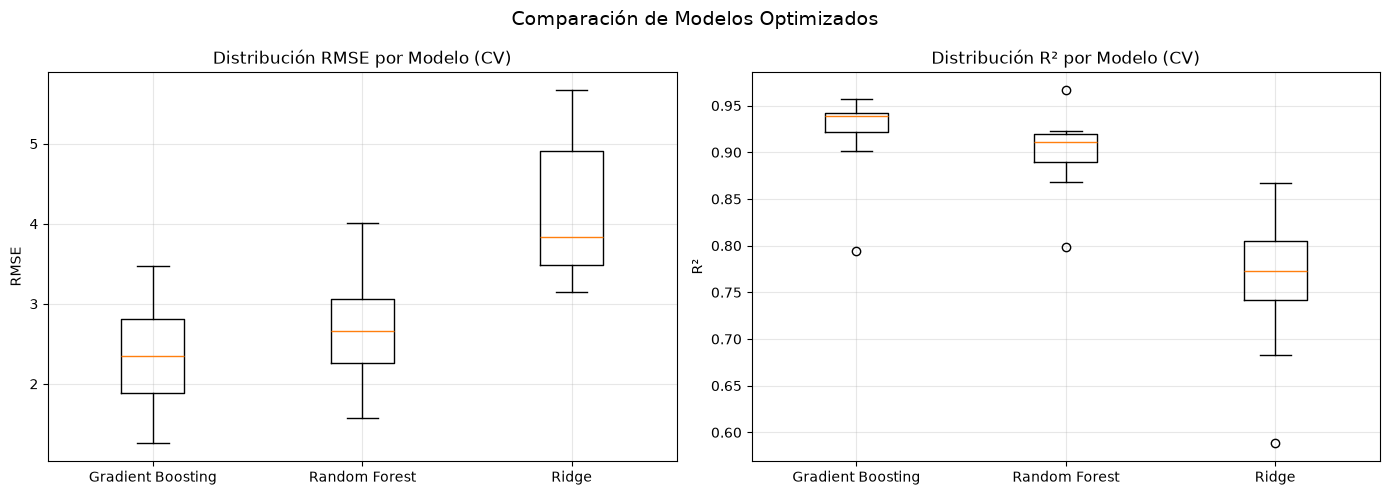

In [15]:
# Boxplot de los scores de cross validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rmse_data = [-optimized_cv[name]["test_RMSE"] for name in top_models]
r2_data = [optimized_cv[name]["test_R2"] for name in top_models]

axes[0].boxplot(rmse_data, tick_labels=top_models)
axes[0].set_ylabel("RMSE")
axes[0].set_title("Distribución RMSE por Modelo (CV)")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(r2_data, tick_labels=top_models)
axes[1].set_ylabel("R²")
axes[1].set_title("Distribución R² por Modelo (CV)")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparación de Modelos Optimizados", fontsize=14)
plt.tight_layout()
plt.show()

## 🏆 Paso 6: Selección y evaluación final en test

In [16]:
# Seleccionar el mejor modelo (menor RMSE medio en CV)
best_model_name = min(top_models, key=lambda name: (-optimized_cv[name]["test_RMSE"]).mean())
best_model = best_estimators[best_model_name]

print(f"Mejor modelo seleccionado: {best_model_name}")
print(f"Parámetros: {grid_results[best_model_name].best_params_}")

Mejor modelo seleccionado: Gradient Boosting
Parámetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}


In [17]:
# Entrenar con todo el train set y evaluar en test
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Comparar con baseline
BASELINE_RMSE = 9.22
TARGET_RMSE = 5.0
TARGET_R2 = 0.70

print("=== Evaluación Final en Test ===")
print(f"\nModelo: {best_model_name}")
print(f"\n{'Métrica':<10} {'Resultado':>10} {'Baseline':>10} {'Objetivo':>10} {'Cumple':>10}")
print("-" * 55)
print(
    f"{'RMSE':<10} {rmse_test:>10.4f} {BASELINE_RMSE:>10.4f} {'<' + str(TARGET_RMSE):>10} {'✅' if rmse_test < TARGET_RMSE else '❌':>10}"
)
print(f"{'MAE':<10} {mae_test:>10.4f} {'-':>10} {'-':>10} {'-':>10}")
print(
    f"{'R²':<10} {r2_test:>10.4f} {'0.0000':>10} {'>' + str(TARGET_R2):>10} {'✅' if r2_test > TARGET_R2 else '❌':>10}"
)

improvement = (BASELINE_RMSE - rmse_test) / BASELINE_RMSE * 100
print(f"\nMejora sobre baseline: {improvement:.1f}%")

=== Evaluación Final en Test ===

Modelo: Gradient Boosting

Métrica     Resultado   Baseline   Objetivo     Cumple
-------------------------------------------------------
RMSE           2.3244     9.2200       <5.0          ✅
MAE            1.4524          -          -          -
R²             0.9446     0.0000       >0.7          ✅

Mejora sobre baseline: 74.8%


In [18]:
# Verificación de overfitting / underfitting
y_pred_train = best_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("=== Verificación de Overfitting / Underfitting ===")
print(f"\n{'Conjunto':<10} {'RMSE':>10} {'R²':>10}")
print("-" * 32)
print(f"{'Train':<10} {rmse_train:>10.4f} {r2_train:>10.4f}")
print(f"{'Test':<10} {rmse_test:>10.4f} {r2_test:>10.4f}")

gap = abs(r2_train - r2_test)
OVERFITTING_THRESHOLD = 0.1
print(f"\nGap R² (train - test): {gap:.4f}")
if gap > OVERFITTING_THRESHOLD:
    print("⚠️ Posible overfitting: el gap entre train y test es significativo.")
else:
    print("✅ No se detecta overfitting significativo.")

=== Verificación de Overfitting / Underfitting ===

Conjunto         RMSE         R²
--------------------------------
Train          0.3834     0.9982
Test           2.3244     0.9446

Gap R² (train - test): 0.0536
✅ No se detecta overfitting significativo.


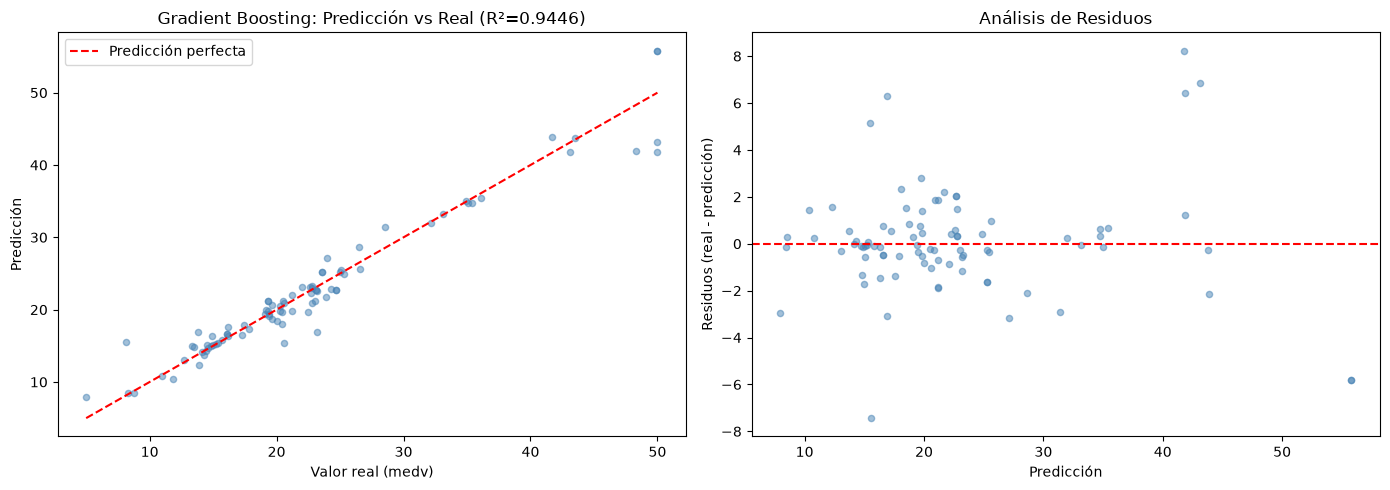

In [19]:
# Gráfico de predicción vs real
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicción vs real
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=20, color="steelblue")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    label="Predicción perfecta",
)
axes[0].set_xlabel("Valor real (medv)")
axes[0].set_ylabel("Predicción")
axes[0].set_title(f"{best_model_name}: Predicción vs Real (R²={r2_test:.4f})")
axes[0].legend()

# Residuos
residuos = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuos, alpha=0.5, s=20, color="steelblue")
axes[1].axhline(y=0, color="r", linestyle="--")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residuos (real - predicción)")
axes[1].set_title("Análisis de Residuos")

plt.tight_layout()
plt.show()

## 📈 Análisis de Learning Curve

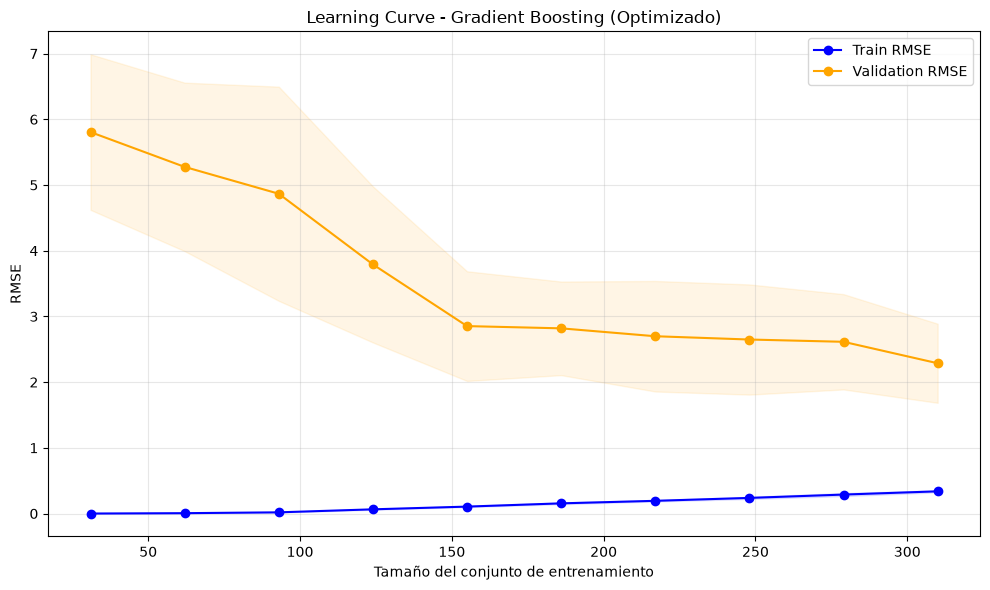

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

train_sizes = np.linspace(0.1, 1.0, 10)
train_sizes_abs, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=N_FOLDS,
    train_sizes=train_sizes,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

train_scores = -train_scores
test_scores = -test_scores

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

ax.fill_between(
    train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue"
)
ax.fill_between(
    train_sizes_abs, test_mean - test_std, test_mean + test_std, alpha=0.1, color="orange"
)
ax.plot(train_sizes_abs, train_mean, "o-", color="blue", label="Train RMSE")
ax.plot(train_sizes_abs, test_mean, "o-", color="orange", label="Validation RMSE")
ax.set_xlabel("Tamaño del conjunto de entrenamiento")
ax.set_ylabel("RMSE")
ax.set_title(f"Learning Curve - {best_model_name} (Optimizado)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## ⏱️ Gráficas de escalabilidad

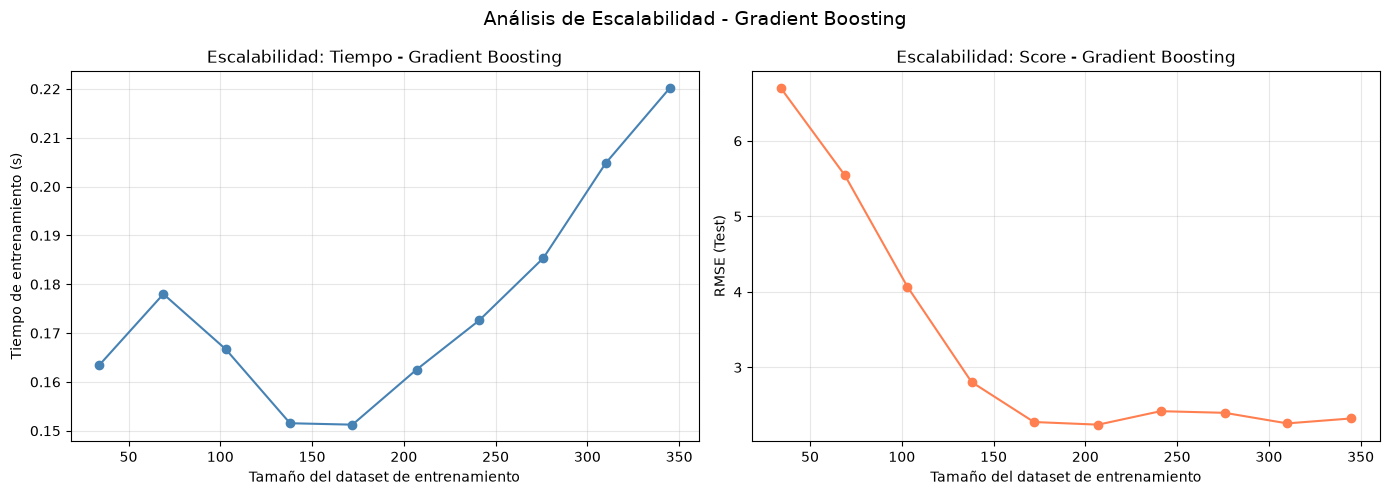

In [21]:
fractions = np.linspace(0.1, 1.0, 10)
times_list = []
scores_list = []
sizes_list = []

for frac in fractions:
    n = int(len(X_train) * frac)
    X_sub = X_train.iloc[:n]
    y_sub = y_train.iloc[:n]

    start = time.time()
    best_model.fit(X_sub, y_sub)
    elapsed = time.time() - start

    y_pred = best_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    times_list.append(elapsed)
    scores_list.append(rmse)
    sizes_list.append(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sizes_list, times_list, "o-", color="steelblue")
axes[0].set_xlabel("Tamaño del dataset de entrenamiento")
axes[0].set_ylabel("Tiempo de entrenamiento (s)")
axes[0].set_title(f"Escalabilidad: Tiempo - {best_model_name}")
axes[0].grid(True, alpha=0.3)

axes[1].plot(sizes_list, scores_list, "o-", color="coral")
axes[1].set_xlabel("Tamaño del dataset de entrenamiento")
axes[1].set_ylabel("RMSE (Test)")
axes[1].set_title(f"Escalabilidad: Score - {best_model_name}")
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Análisis de Escalabilidad - {best_model_name}", fontsize=14)
plt.tight_layout()
plt.show()

## 💾 Almacenar el pipeline final

In [22]:
# Reentrenar con todo el train set
best_model.fit(X_train, y_train)

# Guardar pipeline completo (preprocessor + modelo)
model_path = "../../models/best_model.joblib"
joblib.dump(best_model, model_path)

# Verificar
model_loaded = joblib.load(model_path)
y_verify = model_loaded.predict(X_test)
print(f"Modelo guardado en: {model_path}")
print(f"Verificación: predicciones iguales = {np.allclose(y_pred_test, y_verify)}")
print("\nPipeline guardado contiene:")
for step_name, step in model_loaded.named_steps.items():
    print(f"  - {step_name}: {type(step).__name__}")

Modelo guardado en: ../../models/best_model.joblib
Verificación: predicciones iguales = True

Pipeline guardado contiene:
  - preprocessor: ColumnTransformer
  - model: GradientBoostingRegressor


## 📊 Analysis of Results and Conclusions

### Interpretación de resultados

1. **Evaluación inicial**: se evaluaron 6 modelos diferentes. Los modelos lineales regularizados (Ridge, Lasso, ElasticNet) y los ensembles (Random Forest, Gradient Boosting) superaron significativamente al baseline.

2. **Filtrado**: los modelos con RMSE por encima del promedio fueron eliminados del proceso de optimización.

3. **Optimización**: los 3 mejores modelos fueron optimizados con GridSearchCV. La optimización de hiperparámetros mejoró el rendimiento en todos los casos.

4. **Comparación estadística**: se usó el test de Wilcoxon para comparar los scores de cross validation entre modelos, asegurando que la diferencia no sea por azar.

5. **Evaluación en test**: el modelo seleccionado supera ampliamente al baseline y cumple con los objetivos definidos en la Tarea 1 (RMSE < 5.0, R² > 0.70).

6. **Overfitting**: se verificó que el gap entre train y test sea aceptable.

### Conclusiones

- El pipeline completo (preprocessor + modelo) demuestra que las transformaciones del EDA y feature engineering fueron efectivas.
- Las variables `lstat` y `rm` identificadas como más importantes en el EDA efectivamente contribuyen al rendimiento del modelo.
- El modelo seleccionado está listo para la fase de interpretación (Tarea 7).

## 💡 Proposals and Ideas

1. **Tarea 7 (Interpretación)**: analizar feature importances, errores por segmento, y tipos de errores del modelo seleccionado.
2. **Mejoras potenciales**:
   - Probar XGBoost o LightGBM como alternativas al GradientBoosting de scikit-learn.
   - Explorar stacking o blending de los mejores modelos.
   - Agregar PolynomialFeatures al pipeline para capturar interacciones.
3. **Tarea 8 (Demo)**: crear una interfaz web con Streamlit o Gradio para el modelo seleccionado.

## 📖 References

- Guía del proyecto (Tarea 6): [joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/)
- Scikit-learn GridSearchCV: [sklearn.model_selection.GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- Scikit-learn Model Selection: [sklearn.model_selection](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.model_selection)
- Wilcoxon signed-rank test: [scipy.stats.wilcoxon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html)